In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import calendar
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import tsfeatures as tsf
warnings.filterwarnings('ignore')

pd.set_option('display.max_row', None)

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

fipe_path = './data/merged/dados_fipe_tratados.csv'

df_fipe = pd.read_csv(fipe_path)

df_fipe['sku'] = df_fipe.groupby(['brand_name', 'model_name', 'fuel_name', 'year']).ngroup()

In [2]:
df_teste = df_fipe[(df_fipe['model_name'] == '147 Furgão (todos)') & (df_fipe['year'] == 1987)]

In [3]:
df_teste.index = df_teste['reference_date']

In [4]:
series = df_teste['brl_price']

In [5]:
series

reference_date
2023-09-01    2637.0
2023-10-01    2625.0
2023-11-01    2613.0
2023-12-01    2602.0
2023-01-01    2676.0
2023-02-01    2673.0
2023-03-01    2721.0
2023-04-01    2707.0
2023-05-01    2699.0
2023-06-01    2694.0
2023-07-01    2662.0
2023-08-01    2652.0
2024-01-01    2596.0
2024-02-01    2576.0
2024-03-01    2566.0
2024-04-01    2565.0
2024-05-01    2571.0
2024-06-01    2562.0
2024-07-01    2553.0
2024-08-01    2544.0
2024-09-01    2538.0
2024-10-01    2532.0
2024-11-01    2525.0
2024-12-01    2520.0
2025-01-01    2515.0
2025-02-01    2509.0
2025-03-01    2657.0
2025-04-01    2653.0
2025-05-01    2650.0
2025-06-01    2644.0
2025-08-01    2636.0
2025-09-01    2630.0
2025-10-01    2621.0
2025-11-01    2614.0
2025-12-01    2610.0
2026-01-01    2605.0
2026-02-01    2599.0
2026-03-01    2593.0
2026-04-01    2583.0
2025-07-01    2641.0
Name: brl_price, dtype: float64

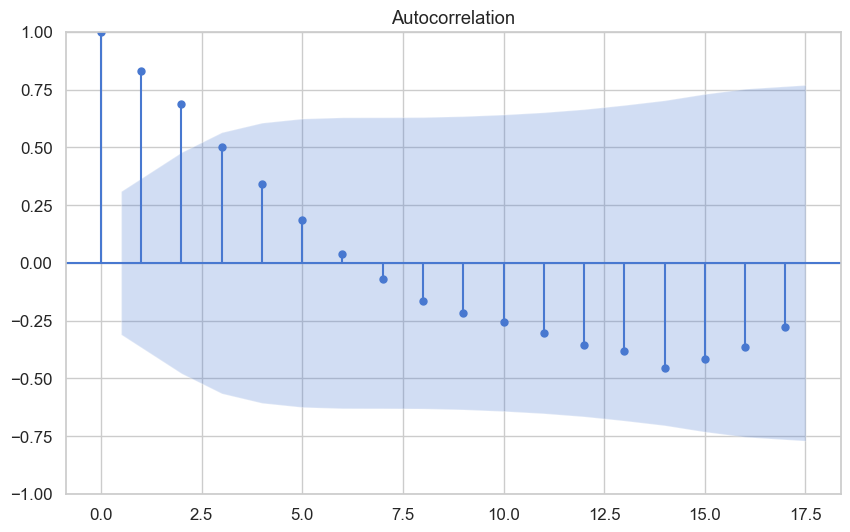

In [6]:
_ = plot_acf(series)

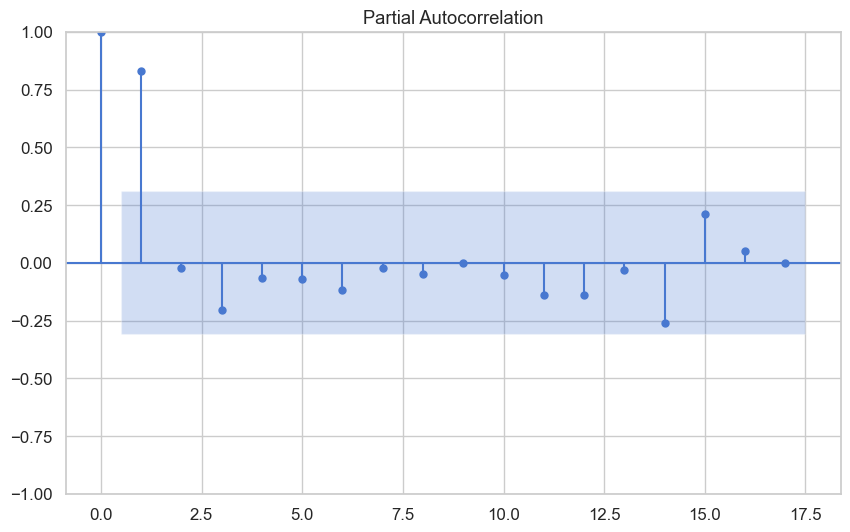

In [7]:
_ = plot_pacf(series)

In [8]:
df = series.to_frame()

In [9]:
df['brl_price_shift'] = df['brl_price'].shift(6)

In [10]:
df

,brl_price,brl_price_shift
reference_date,,
2023-09-01,2637.0,NaN
2023-10-01,2625.0,NaN
2023-11-01,2613.0,NaN
2023-12-01,2602.0,NaN
2023-01-01,2676.0,NaN
2023-02-01,2673.0,NaN
2023-03-01,2721.0,2637.0
2023-04-01,2707.0,2625.0
2023-05-01,2699.0,2613.0


<Axes: xlabel='brl_price_shift', ylabel='brl_price'>

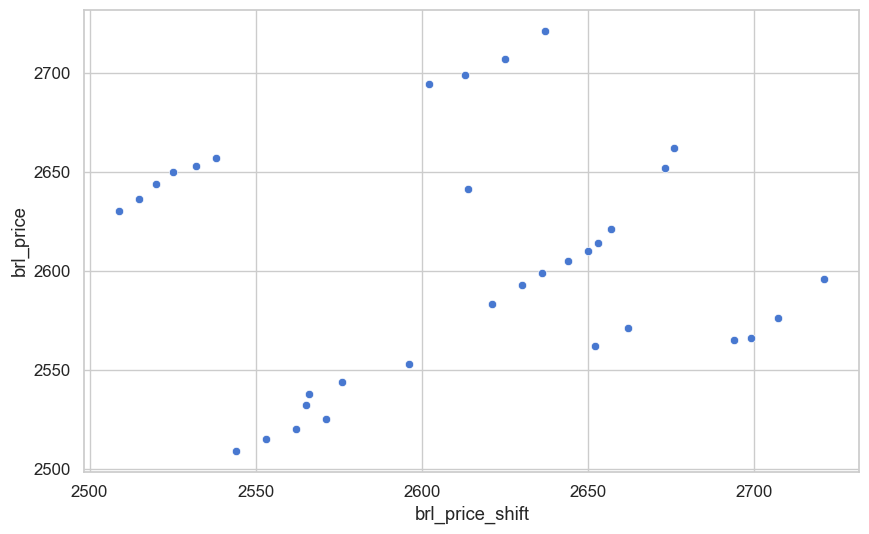

In [11]:
sns.scatterplot(df, x='brl_price_shift', y='brl_price')

In [12]:
df.corr()

,brl_price,brl_price_shift
brl_price,1.000000,0.042697
brl_price_shift,0.042697,1.000000


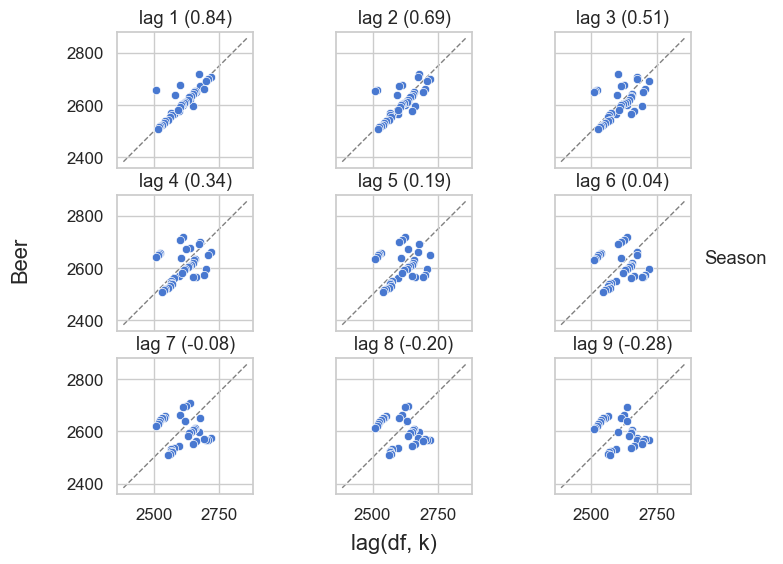

In [13]:
lims = .95 * df["brl_price"].min(), 1.05 * df["brl_price"].max()
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    df = df.assign(lag=df["brl_price"].shift(lag))
    sns.scatterplot(data=df, x="lag", y="brl_price", ax=ax)
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag} ({df.corr()['brl_price']['lag']:.2f})", xlabel="", ylabel="", aspect="equal")
    # ax.get_legend().remove()
axes[1, -1].legend(loc="center left", title="Season",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.supxlabel("lag(df, k)")
fig.supylabel("Beer")
fig.show()

In [12]:
df_onix = df_fipe[df_fipe['model_name'].str.contains('ONIX')]

In [13]:
df_onix = df_onix[df_onix['year'] == 2017]

In [16]:
skus = [3845, 3923, 6776, 7192, 1817, 80]

In [17]:
df_fipe['reference_date'] = pd.to_datetime(df_fipe['reference_date'])

In [20]:
df_fipe = df_fipe.sort_values(by='reference_date')

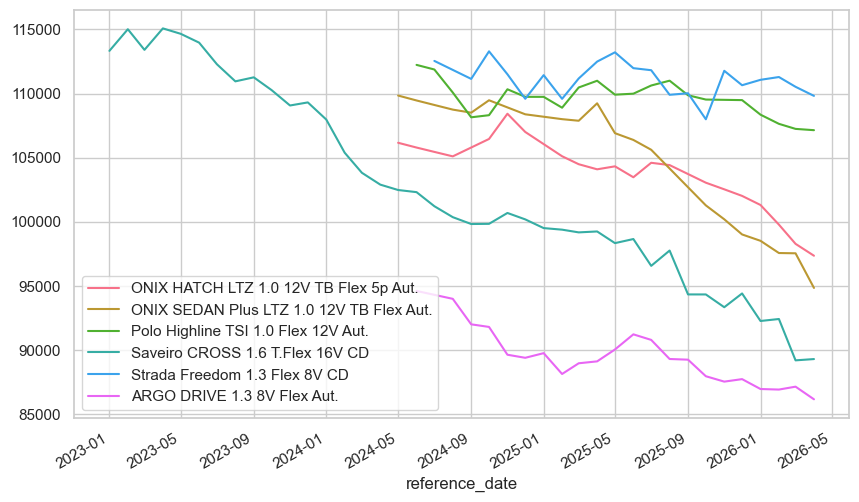

In [25]:
palette = sns.color_palette("husl", n_colors=len(skus))
color_map = dict(zip(skus, palette))

fig, ax = plt.subplots()
for sku in skus:
    df_sku = df_fipe[df_fipe['sku'] == sku].copy()
    df_sku.plot(
        x="reference_date",
        y="brl_price",
        ax=ax, 
        color=color_map[sku],
        label=df_sku['model_name'].iloc[0]
    )

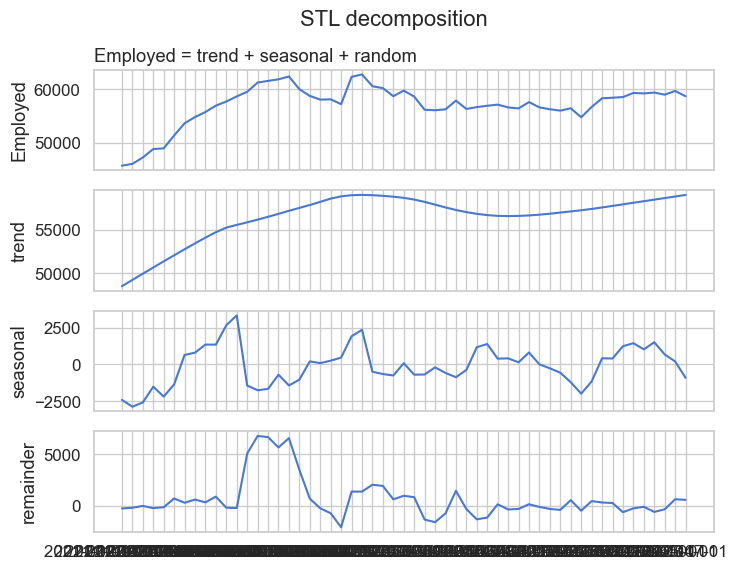

In [15]:
df_teste = df_fipe[df_fipe['sku'] == 3858]

stl = STL(df_teste["brl_price"], period=12,
    seasonal=13, trend=21, robust=True)
res_stl = stl.fit()

dcmp = pd.DataFrame({
    "ds": df_teste["reference_date"],
    "data": df_teste["brl_price"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + random",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

In [17]:
stl_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10).iloc[:, :5]

NameError: name 'aus_tourism' is not defined